In [179]:
import numpy as np
import pandas as pd
import seaborn as sns
import re

In [149]:
df = pd.read_csv('/kaggle/input/datasets/samvelgalstyan/nomenclature/30.09.2026 13.11.42.csv')

In [150]:
df.head()

,Группа,Артикул,Название
0,Ջրեղեն,9900671,Կոմպոտ Անանաս և կիվի
1,Տնտեսական ներքին օգտագործում,990499,Օճառ Փրփուր 1 Լ
2,Տնտեսական ներքին օգտագործում,990536,A 3 ֆորմատի թուղթ
3,Տնտեսական ներքին օգտագործում,983171,A 4 ֆորմատի թուղթ 500 հատ
4,Տնտեսական ներքին օգտագործում,9900417,Alpi Универсальный 20 կգ․ լվացքի փոշի ունիվերս...


In [151]:
df.isna().sum()

Группа      0
Артикул     0
Название    0
dtype: int64

In [152]:
df['Группа'].nunique()

18

In [153]:
df['Группа'].value_counts()

Группа
Տնտեսական ներքին օգտագործում    862
Բակալեա                         427
SWEET                           257
Ջրեղեն                          252
Միս, մսամթերք                   171
Կաթնամթերք                      150
Պրոյեկտի համար                  147
Միրգ, բանջարեղեն                133
Համեմունքներ, սերմեր             88
Հացեր                            50
Գյուղ. մթերքներ                  19
Սուրճ, թեյ                       18
Ծամոն                            17
SAS ձկնեղեն                      14
Խորովելու                        10
Վերավաճառվող ապրանքներ            7
Խաշելու                           5
Սկզբնական մնացորդ                 2
Name: count, dtype: int64

In [154]:
df[df.duplicated(subset=['Название'], keep=False)].sort_values('Название')

,Группа,Артикул,Название
238,SWEET,988794,Пироженное SAS Sweet сигареты
239,SWEET,177378,Пироженное SAS Sweet сигареты
576,Տնտեսական ներքին օգտագործում,988848,Ավտոմատ 32A
577,Տնտեսական ներքին օգտագործում,988850,Ավտոմատ 32A


In [188]:
df_cleaned = df.drop_duplicates(subset=['Название'], keep='first').copy()

print(f"Исходное количество строк: {len(df)}")
print(f"После удаления дубликатов названий: {len(df_cleaned)}")


Исходное количество строк: 2629
После удаления дубликатов названий: 2627


In [189]:
def detect_language(text):
    if re.search(r'[ա-ֆԱ-ֆ]', text):
        return 'Armenian'
    elif re.search(r'[а-яА-Я]', text):
        return 'Russian'
    elif re.search(r'[a-zA-Z]', text):
        return 'English'
    return 'Other'

df_cleaned['Язык'] = df_cleaned['Название'].apply(detect_language)

In [190]:
df_cleaned.groupby(['Группа', 'Язык']).size()

Группа                        Язык    
SAS ձկնեղեն                   Armenian      9
                              Russian       5
SWEET                         Armenian    102
                              Russian     154
Բակալեա                       Armenian    425
                              Russian       2
Գյուղ. մթերքներ               Armenian     19
Խաշելու                       Armenian      5
Խորովելու                     Armenian     10
Ծամոն                         Armenian      3
                              Russian      14
Կաթնամթերք                    Armenian    148
                              Russian       2
Համեմունքներ, սերմեր          Armenian     88
Հացեր                         Armenian     50
Միս, մսամթերք                 Armenian    171
Միրգ, բանջարեղեն              Armenian    133
Պրոյեկտի համար                Armenian    147
Ջրեղեն                        Armenian    105
                              English      16
                              Russian    

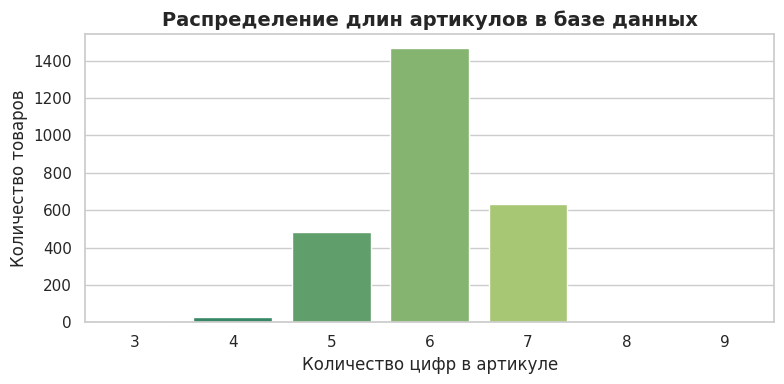

In [201]:
plt.figure(figsize=(8, 4))
df_cleaned['Длина_артикула'] = df_cleaned['Артикул'].astype(str).str.len()
sns.countplot(data=df_cleaned, x='Длина_артикула', hue='Длина_артикула', palette='summer', legend=False)
plt.title('Распределение длин артикулов в базе данных', fontsize=14, fontweight='bold')
plt.xlabel('Количество цифр в артикуле')
plt.ylabel('Количество товаров')
plt.tight_layout()